In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/dataset/train"
valid_path = "/content/drive/MyDrive/dataset/valid"

In [ ]:
train_gen = ImageDataGenerator(
    rescale=1./255
)

valid_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_gen.flow_from_directory(
    valid_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8619 images belonging to 3 classes.
Found 2240 images belonging to 3 classes.


In [ ]:
print("Jumlah Kelas :", train_data.num_classes)
print("Nama Kelas :", list(train_data.class_indices.keys()))

Jumlah Kelas : 3
Nama Kelas : ['Early_blight', 'Late_blight', 'healthy']


In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
mobilenet_model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')

])

In [ ]:
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10
)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 2898s 11s/step - accuracy: 0.8429 - loss: 0.3821 - val_accuracy: 0.8875 - val_loss: 0.2618
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 62s 228ms/step - accuracy: 0.9313 - loss: 0.1833 - val_accuracy: 0.9321 - val_loss: 0.1783
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 60s 224ms/step - accuracy: 0.9546 - loss: 0.1278 - val_accuracy: 0.9317 - val_loss: 0.1659
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 61s 224ms/step - accuracy: 0.9661 - loss: 0.0932 - val_accuracy: 0.9393 - val_loss: 0.1651
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 60s 224ms/step - accuracy: 0.9719 - loss: 0.0783 - val_accuracy: 0.9464 - val_loss: 0.1567
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 90s 253ms/step - accuracy: 0.9788 - loss: 0.0587 - val_accuracy: 0.9518 - val_loss: 0.1369
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 60s 222ms/step - accuracy: 0.9832 - loss: 0.0477 - val_accuracy: 0.9531 - val_loss: 0.1403
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 67s 248ms/step - accuracy: 0.9857 - loss: 0

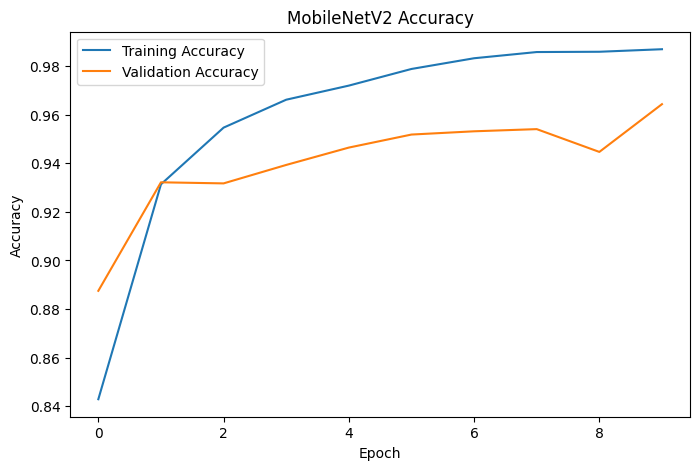

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

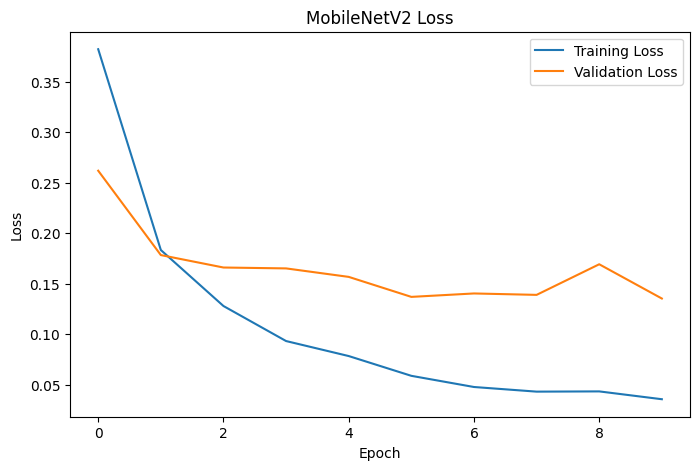

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step


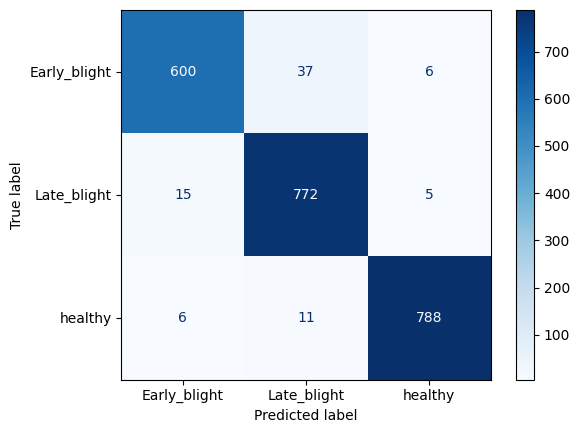

In [ ]:
valid_data.reset()

pred = mobilenet_model.predict(valid_data)

pred_class = np.argmax(pred, axis=1)

cm = confusion_matrix(valid_data.classes, pred_class)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(valid_data.class_indices.keys())
)

disp.plot(cmap="Blues")

plt.show()

In [ ]:
print(classification_report(
    valid_data.classes,
    pred_class,
    target_names=list(valid_data.class_indices.keys())
))

              precision    recall  f1-score   support

Early_blight       0.97      0.93      0.95       643
 Late_blight       0.94      0.97      0.96       792
     healthy       0.99      0.98      0.98       805

    accuracy                           0.96      2240
   macro avg       0.96      0.96      0.96      2240
weighted avg       0.96      0.96      0.96      2240



In [ ]:
mobilenet_model.save("MobileNetV2_Tomato.keras")

Saving fbbe43eb-7d70-4053-97ac-908fb9af1a6f___RS_Late.B 6587.JPG to fbbe43eb-7d70-4053-97ac-908fb9af1a6f___RS_Late.B 6587.JPG


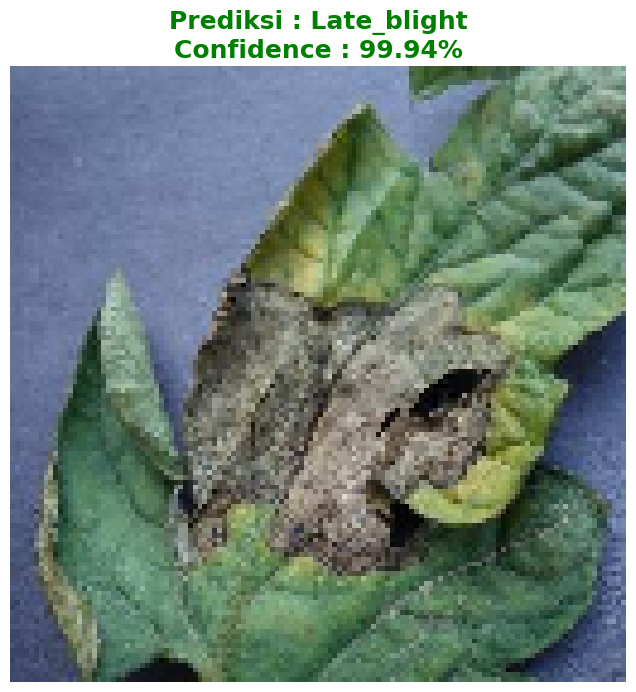

HASIL PREDIKSI
Prediksi   : Late_blight
Confidence : 99.94%


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

uploaded = files.upload()

img_path = next(iter(uploaded))

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

prediction = mobilenet_model.predict(img_array, verbose=0)

class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediksi : {predicted_class}\nConfidence : {confidence:.2f}%",
    fontsize=18,
    fontweight="bold",
    color="green"
)

plt.show()

print("="*40)
print("HASIL PREDIKSI")
print("="*40)
print("Prediksi   :", predicted_class)
print(f"Confidence : {confidence:.2f}%")